<a href="https://colab.research.google.com/github/AbelAtares/delaney-solubility-descriptors-linear-regression-random-forest/blob/main/Breast-Cancer-Logistic-Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Logistic Regression**

### **Import and study data**

svd

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/ganapap1/Logistic_Regression/refs/heads/main/breastcancer.csv')
df

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,benign
1,1002945,5,4,4,5,7,10,3,2,1,benign
2,1015425,3,1,1,1,2,2,3,1,1,benign
3,1016277,6,8,8,1,3,4,3,7,1,benign
4,1017023,4,1,1,3,2,1,3,1,1,benign
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,benign
679,841769,2,1,1,1,2,1,1,1,1,benign
680,888820,5,10,10,3,7,3,8,10,2,malignant
681,897471,4,8,6,4,3,4,10,6,1,malignant


In [ ]:
df["Class"] = df["Class"].map({"benign": 0, "malignant": 1})
df

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,0
679,841769,2,1,1,1,2,1,1,1,1,0
680,888820,5,10,10,3,7,3,8,10,2,1
681,897471,4,8,6,4,3,4,10,6,1,1


In [ ]:
malignant = df[df["Class"] == 1]
benign = df[df["Class"] == 0]

In [ ]:
malignant

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
5,1017122,8,10,10,8,7,10,9,7,1,1
12,1041801,5,3,3,3,2,3,4,4,1,1
14,1044572,8,7,5,10,7,9,5,5,4,1
15,1047630,7,4,6,4,6,1,4,3,1,1
18,1050670,10,7,7,6,4,10,4,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...
665,1371026,5,10,10,10,4,10,5,6,3,1
675,695091,5,10,10,5,4,5,4,4,1,1
680,888820,5,10,10,3,7,3,8,10,2,1
681,897471,4,8,6,4,3,4,10,6,1,1


In [ ]:
benign

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
674,654546,1,1,1,3,2,1,1,1,1,0
676,714039,3,1,1,1,2,1,1,1,1,0
677,763235,3,1,1,1,2,1,2,1,2,0
678,776715,3,1,1,1,3,2,1,1,1,0


In [ ]:
malignant.describe()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
count,2.390000e+02,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.0
mean,1.005121e+06,7.188285,6.577406,6.560669,5.585774,5.326360,7.627615,5.974895,5.857741,2.602510,1.0
std,3.223021e+05,2.437907,2.724244,2.569104,3.196631,2.443087,3.116679,2.282422,3.348876,2.564495,0.0
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
25%,8.323965e+05,5.000000,4.000000,4.000000,3.000000,3.000000,5.000000,4.000000,3.000000,1.000000,1.0
50%,1.142706e+06,8.000000,6.000000,6.000000,5.000000,5.000000,10.000000,7.000000,6.000000,1.000000,1.0
75%,1.221955e+06,10.000000,10.000000,9.000000,8.000000,6.500000,10.000000,7.000000,9.500000,3.000000,1.0
max,1.371026e+06,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.0


In [ ]:
benign.describe()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
count,4.440000e+02,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.0
mean,1.115261e+06,2.963964,1.306306,1.414414,1.346847,2.108108,1.346847,2.083333,1.261261,1.065315,0.0
std,7.300359e+05,1.672661,0.855657,0.957031,0.917088,0.877112,1.177848,1.062299,0.954606,0.509738,0.0
min,1.280590e+05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0
25%,1.016064e+06,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0
50%,1.180677e+06,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.0
75%,1.257846e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.0
max,1.345435e+07,8.000000,9.000000,8.000000,10.000000,10.000000,10.000000,7.000000,8.000000,8.000000,0.0


In [ ]:
df.corr()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
Id,1.000000,-0.056350,-0.041396,-0.042221,-0.069630,-0.048644,-0.099248,-0.061966,-0.050699,-0.037972,-0.084701
Cl.thickness,-0.056350,1.000000,0.642481,0.653470,0.487829,0.523596,0.593091,0.553742,0.534066,0.350957,0.714790
Cell.size,-0.041396,0.642481,1.000000,0.907228,0.706977,0.753544,0.691709,0.755559,0.719346,0.460755,0.820801
Cell.shape,-0.042221,0.653470,0.907228,1.000000,0.685948,0.722462,0.713878,0.735344,0.717963,0.441258,0.821891
Marg.adhesion,-0.069630,0.487829,0.706977,0.685948,1.000000,0.594548,0.670648,0.668567,0.603121,0.418898,0.706294
Epith.c.size,-0.048644,0.523596,0.753544,0.722462,0.594548,1.000000,0.585716,0.618128,0.628926,0.480583,0.690958
Bare.nuclei,-0.099248,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210,0.822696
Bl.cromatin,-0.061966,0.553742,0.755559,0.735344,0.668567,0.618128,0.680615,1.000000,0.665602,0.346011,0.758228
Normal.nucleoli,-0.050699,0.534066,0.719346,0.717963,0.603121,0.628926,0.584280,0.665602,1.000000,0.433757,0.718677
Mitoses,-0.037972,0.350957,0.460755,0.441258,0.418898,0.480583,0.339210,0.346011,0.433757,1.000000,0.423448


In [ ]:
df=df[['Bare.nuclei','Class']]
df.head(30)

,Bare.nuclei,Class
0,1,0
1,10,0
2,2,0
3,4,0
4,1,0
5,10,1
6,10,0
7,1,0
8,1,0
9,1,0


In [ ]:
df = df.rename(columns={"Bare.nuclei": "Bare_nuclei"})
df.head()

,Bare_nuclei,Class
0,1,0
1,10,0
2,2,0
3,4,0
4,1,0


### **Data visualization**

In [ ]:
from matplotlib import pyplot as plt

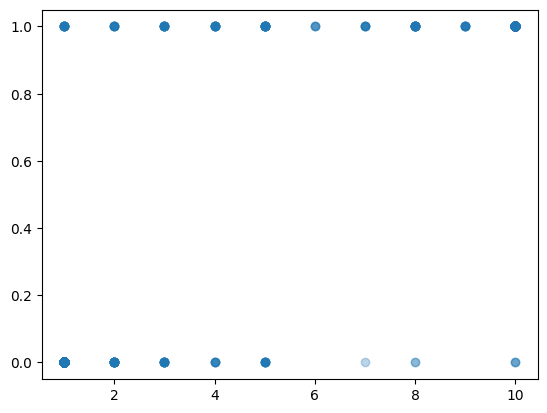

In [ ]:
plt.scatter(df.Bare_nuclei,df.Class,alpha=0.3)

### **Data split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.Bare_nuclei,df.Class,test_size=0.2,random_state=11)

In [ ]:
X_train,X_test,y_train,y_test

(554     5
 293    10
 654     8
 104    10
 447     1
        ..
 332     1
 269     1
 337     1
 91      1
 80      1
 Name: Bare_nuclei, Length: 546, dtype: int64,
 442    3
 387    1
 217    8
 137    1
 423    1
       ..
 616    1
 605    2
 429    1
 635    1
 198    1
 Name: Bare_nuclei, Length: 137, dtype: int64,
 554    1
 293    1
 654    1
 104    1
 447    0
       ..
 332    0
 269    0
 337    0
 91     0
 80     0
 Name: Class, Length: 546, dtype: int64,
 442    1
 387    0
 217    1
 137    0
 423    0
       ..
 616    0
 605    0
 429    0
 635    0
 198    0
 Name: Class, Length: 137, dtype: int64)

### **Model implementation**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr=LogisticRegression()
lr.fit(X_train.values.reshape(-1,1),y_train)

LogisticRegression()

### **Prediction**

In [ ]:
y_pred=lr.predict(X_test.values.reshape(-1,1))
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0])

In [ ]:
y_test

,Class
442,1
387,0
217,1
137,0
423,0
...,...
616,0
605,0
429,0
635,0


In [ ]:
lr.predict_proba(X_test.values.reshape(-1,1))

array([[0.72452356, 0.27547644],
       [0.93438119, 0.06561881],
       [0.0371293 , 0.9628707 ],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.00707195, 0.99292805],
       [0.00707195, 0.99292805],
       [0.00707195, 0.99292805],
       [0.93438119, 0.06561881],
       [0.32695321, 0.67304679],
       [0.00707195, 0.99292805],
       [0.0371293 , 0.9628707 ],
       [0.93438119, 0.06561881],
       [0.00707195, 0.99292805],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.93438119, 0.06561881],
       [0.00707195, 0.99292805],
       [0.00707195, 0.99292805],
       [0.93438119, 0.06561881],
       [0.85954513, 0.14045487],
       [0.93438119, 0.06561881],
       [0.85954513, 0.14045487],
       [0.93438119, 0.06561881],
       [0.00707195, 0.99292805],
       [0.93438119, 0.06561881],
       [0.00707195, 0.99292805],
       [0.

### **Model Performance**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[84,  2],
       [10, 41]])

In [ ]:
lr.score(X_test.values.reshape(-1,1),y_test) #Accuracy

0.9124087591240876

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy Score: 0.9124087591240876

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93        86
           1       0.95      0.80      0.87        51

    accuracy                           0.91       137
   macro avg       0.92      0.89      0.90       137
weighted avg       0.92      0.91      0.91       137

ROC AUC Score: 0.8903328773369812
